In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme()

Number of actions: 3529450


<Axes: ylabel='Frequency'>

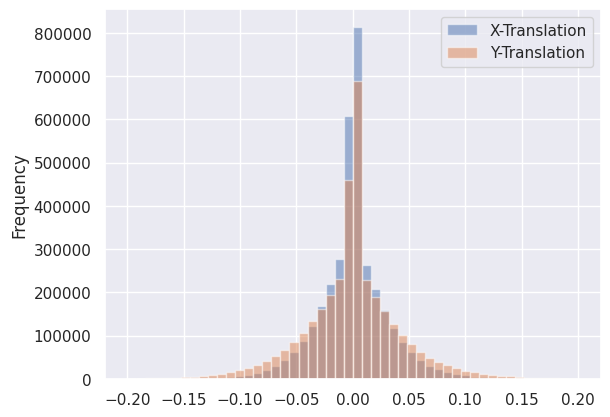

In [5]:
# get parent directory
import os
parent_dir = os.path.dirname(os.getcwd())
df = pd.read_csv(f"{parent_dir}/csv/actions.csv", header=0, names=["X-Translation", "Y-Translation"], delimiter=" ")
print(f"Number of actions: {len(df)}")
df.plot.hist(bins=50, alpha=0.5, range=[-0.2,0.2])
# plt.savefig("action_dist.svg", bbox_inches="tight")

In [3]:
df.describe()

,X-Translation,Y-Translation
count,3.529450e+06,3.529450e+06
mean,1.718155e-04,-5.747184e-04
std,3.028779e-02,4.248353e-02
min,-2.198996e-01,-2.347823e-01
25%,-1.315916e-02,-1.986500e-02
50%,0.000000e+00,0.000000e+00
75%,1.257578e-02,1.829603e-02
max,2.320783e-01,2.449680e-01


In [5]:
df.value_counts()

X-Translation  Y-Translation
 0.000000e+00   0.000000e+00    221306
 5.000000e-02   5.000000e-02     30511
-5.000000e-02  -5.000000e-02     24788
 5.000000e-02  -5.000000e-02     24526
-5.000000e-02   5.000000e-02     22900
                                 ...  
-2.516151e-03  -1.555309e-07         1
-2.516180e-03   3.100656e-02         1
-2.516210e-03  -2.238041e-02         1
-2.516359e-03   5.000000e-02         1
-6.556511e-07  -2.234250e-02         1
Name: count, Length: 2223765, dtype: int64

minimum: [-0.21989956 -0.23478234]
maximum: [0.23207834 0.24496803]


<Axes: ylabel='Frequency'>

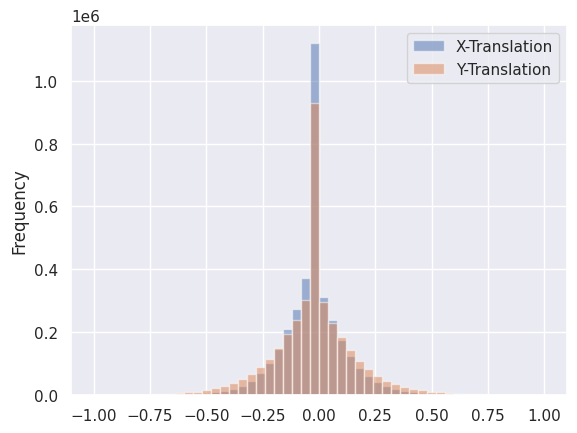

In [25]:
df = pd.read_csv(f"{parent_dir}/csv/actions.csv", header=0, names=["X-Translation", "Y-Translation"], delimiter=" ")

minimum = df.min().values
maximum = df.max().values
print("minimum:", minimum)
print("maximum:", maximum)

def min_max_norm(x, minimum, maximum):
    x -= minimum
    x /= (maximum - minimum)
    x *= 2
    x -= 1  # scale to [-1, 1]
    return x

df["X-Translation"] = min_max_norm(df["X-Translation"], minimum[0], maximum[0])
df["Y-Translation"] = min_max_norm(df["Y-Translation"], minimum[1], maximum[1])

df.plot.hist(bins=50, alpha=0.5, range=[-1,1])